In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)


In [9]:
df = pd.read_csv(r"C:\Users\mitta_9mbfbiz\Downloads\store_customers.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (1000, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0



Missing values:
CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64


In [10]:
# Select the two features commonly useful for customer segmentation
features = ["Annual Income (k$)", "Spending Score (1-100)"]

X = df[features].copy()

print("Features used for clustering:")
display(X.head())


Features used for clustering:


,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


In [15]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]

X = df[features].copy()

# Remove rows with missing values
X = X.dropna()

print("Missing values:")
print(X.isnull().sum())

print("Shape after removing missing values:", X.shape)

Missing values:
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Shape after removing missing values: (990, 2)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled data shape:", X_scaled.shape)

Scaled data shape: (990, 2)


C:\Users\mitta_9mbfbiz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\mitta_9mbfbiz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\mitta_9mbfbiz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\mitta_9mbfbiz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known

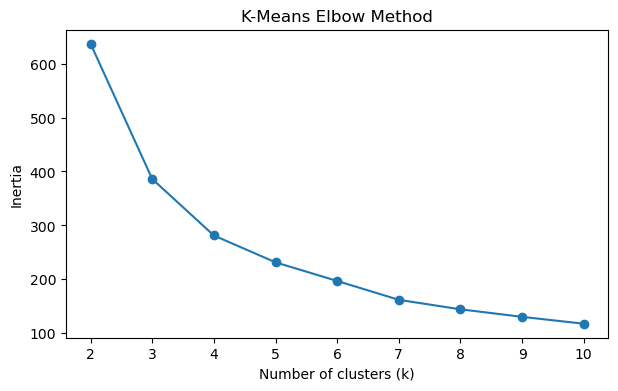

In [17]:
inertias = []
k_values = range(2, 11)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")
plt.show()

In [19]:
features = ["Annual Income (k$)", "Spending Score (1-100)"]

# Remove rows with missing values from the original dataframe
df = df.dropna(subset=features).reset_index(drop=True)

X = df[features].copy()

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dataset shape:", df.shape)
print("Missing values:")
print(X.isnull().sum())

Dataset shape: (990, 5)
Missing values:
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [20]:
# Use 5 clusters for customer segmentation
kmeans = KMeans(n_clusters=5, n_init=10, random_state=42)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

print("K-Means cluster counts:")
print(df["KMeans_Cluster"].value_counts().sort_index())

K-Means cluster counts:
KMeans_Cluster
0    204
1    126
2    197
3    155
4    308
Name: count, dtype: int64


C:\Users\mitta_9mbfbiz\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


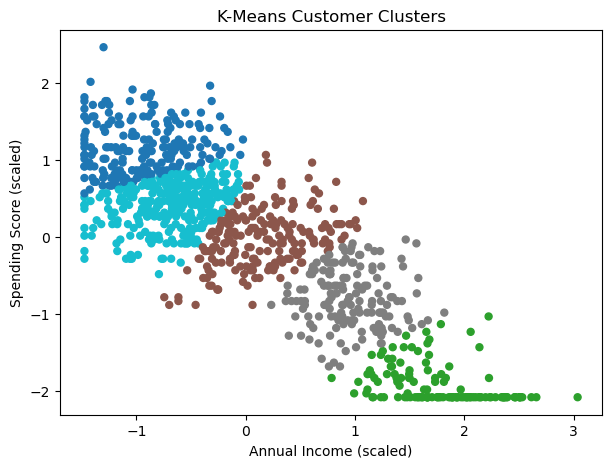

In [21]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=kmeans_labels, cmap="tab10", s=25
)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("K-Means Customer Clusters")
plt.show()


In [22]:
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means Silhouette Score: {kmeans_score:.3f}")


K-Means Silhouette Score: 0.359


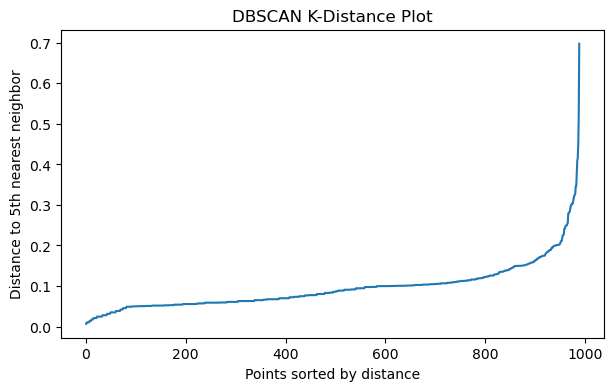

In [23]:
min_samples = 5

from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 4))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("DBSCAN K-Distance Plot")
plt.show()


In [24]:
# Try a few eps values and compare the number of clusters/noise points
for eps in [0.25, 0.35, 0.45, 0.55]:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    print(f"eps={eps}: clusters={n_clusters}, noise points={n_noise}")


eps=0.25: clusters=2, noise points=10
eps=0.35: clusters=1, noise points=2
eps=0.45: clusters=1, noise points=1
eps=0.55: clusters=1, noise points=0


In [25]:
# Final DBSCAN model
dbscan = DBSCAN(eps=0.35, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = np.sum(dbscan_labels == -1)

print("DBSCAN clusters:", n_clusters_db)
print("DBSCAN noise points:", n_noise_db)


DBSCAN clusters: 1
DBSCAN noise points: 2


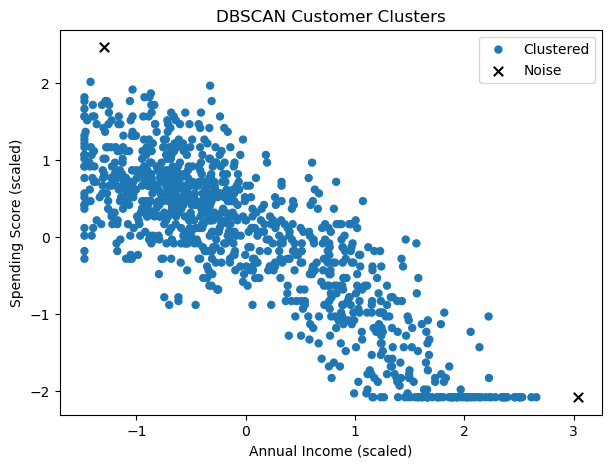

In [26]:
plt.figure(figsize=(7, 5))

noise_mask = dbscan_labels == -1
cluster_mask = ~noise_mask

plt.scatter(
    X_scaled[cluster_mask, 0],
    X_scaled[cluster_mask, 1],
    c=dbscan_labels[cluster_mask],
    cmap="tab10",
    s=25,
    label="Clustered"
)

plt.scatter(
    X_scaled[noise_mask, 0],
    X_scaled[noise_mask, 1],
    c="black",
    marker="x",
    s=45,
    label="Noise"
)

plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("DBSCAN Customer Clusters")
plt.legend()
plt.show()


In [27]:
# Silhouette score is calculated only when DBSCAN produces at least
# two clusters after excluding noise points.
db_mask = dbscan_labels != -1

if n_clusters_db >= 2 and db_mask.sum() > n_clusters_db:
    dbscan_score = silhouette_score(X_scaled[db_mask], dbscan_labels[db_mask])
    print(f"DBSCAN Silhouette Score (excluding noise): {dbscan_score:.3f}")
else:
    dbscan_score = np.nan
    print("Silhouette score cannot be calculated for the current DBSCAN result.")


Silhouette score cannot be calculated for the current DBSCAN result.


In [28]:
agg = AgglomerativeClustering(n_clusters=5, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

df["Agglomerative_Cluster"] = agg_labels

print("Agglomerative cluster counts:")
print(df["Agglomerative_Cluster"].value_counts().sort_index())


Agglomerative cluster counts:
Agglomerative_Cluster
0    402
1    183
2    142
3    177
4     86
Name: count, dtype: int64


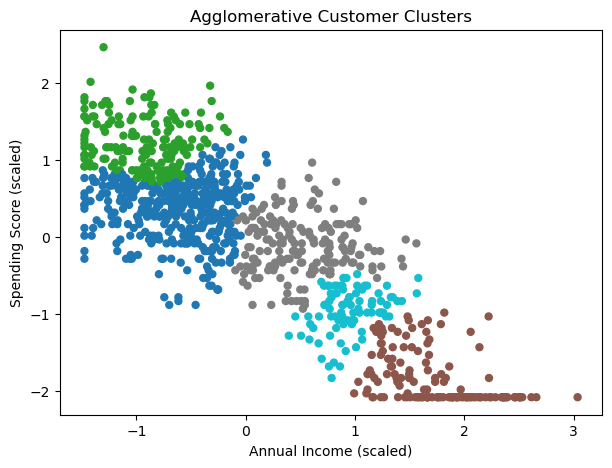

In [29]:
plt.figure(figsize=(7, 5))
plt.scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=agg_labels, cmap="tab10", s=25
)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Agglomerative Customer Clusters")
plt.show()


In [30]:
agg_score = silhouette_score(X_scaled, agg_labels)
print(f"Agglomerative Silhouette Score: {agg_score:.3f}")


Agglomerative Silhouette Score: 0.322
